In [35]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from collections import Counter
from tqdm.notebook import tqdm
from deeptime.clustering import KMeans
from deeptime.clustering import RegularSpace
from deeptime.clustering import BoxDiscretization
import pandas as pd 
import pyemma

import mdtraj as md
import re, math, os, shutil, pickle

import warnings; warnings.simplefilter('ignore')
from collections import Counter

## Important Functions

In [36]:
class Data:
    def __init__(self, array_list):
        self.array_list = array_list

    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.array_list, f)

    @classmethod
    def load(cls, filename):
        with open(filename, 'rb') as f:
            array_list = pickle.load(f)
        return cls(array_list)

In [37]:
# Define the directory path
directory = "clustering/"

remove_and_clean = True

# Check if the directory exists
if os.path.exists(directory):
    if remove_and_clean:
        # Remove all contents of the directory
        shutil.rmtree(directory)
        # Recreate the empty directory
        os.makedirs(directory)
        print(f"All contents in '{directory}' have been cleared.")
    else:
        print(f"Directory '{directory}' already exists. No action taken.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'clustering/' have been cleared.


## Load the data

In [38]:
## Load Distance Restraubt Data 
dist_path = f"traj_data/dist_state0.pkl"
dist = Data.load(dist_path)
dist = dist.array_list
print(f'dist.shape:{np.array(dist).shape}')

## Load Backbone Phi Omega angle 
omega_path = f"traj_data/omegas_state0.pkl"
omegas = Data.load(omega_path)
omegas = omegas.array_list
print(f'omegas.shape: {np.array(omegas).shape}')

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed

omega_indices = [r for r in residues_to_plot]
phi_indices   = [r + 1 for r in residues_to_plot]
psi_indices   = [r + 2 for r in residues_to_plot]
chi1_indices  = [r + 3 for r in residues_to_plot]

for angle_indices in [omega_indices, psi_indices, chi1_indices]:
    omegas[:, angle_indices] = (omegas[:, angle_indices] + 90.0) % 360.0 - 90.0

feat_all = np.hstack([dist,omegas])
print('feat_all.shape', feat_all.shape)

dist.shape:(200010, 90)
omegas.shape: (200010, 24)
feat_all.shape (200010, 114)


## Clustering with Selected Backbone Angle 

In [39]:
residues_to_plot = np.arange(0, 24, 4).tolist()  # [0, 4, 8, 12, 16, 20]
omega_features = feat_all[:, -24:]              # Get the last 24 columns
selected_omegas = omega_features[:, residues_to_plot]
selected_phi = omega_features[:, [i + 1 for i in residues_to_plot]]
selected_psi = omega_features[:, [i + 2 for i in residues_to_plot]]
selected_khi = omega_features[:, [i + 3 for i in residues_to_plot]]

In [40]:
omega_binary = (selected_omegas > 90).astype(int)  # 1 if > 90, else 0
phi_binary = (selected_phi > 0).astype(int)        # 1 if > 0, else 0


In [41]:
backbone_signature = np.hstack([omega_binary, phi_binary])  # shape (200010, 12)
backbone_signature.shape

(200010, 12)

In [42]:
# Convert each row to a tuple so they are hashable
signatures = [tuple(row) for row in backbone_signature]

# Map to integer labels
df_signatures = pd.DataFrame(signatures, columns=[f"f{i}" for i in range(12)])
df_signatures["cluster_label"] = pd.factorize(signatures)[0]  # returns labels 0, 1, 2, ...

# Final cluster labels:
assignments = df_signatures["cluster_label"].to_numpy()

assignments.shape

(200010,)

In [43]:
# count the number of each cluter 
counts = Counter(assignments)
#print(counts)

# Sort the counts 
sorted_counts = dict(sorted(counts.items()))
total_counts = sum(counts.values())
cluster = []

# Create a DataFrame to hold results
data = {
    "Cluster Label": [],
    "Count": [],
    "Population": []
}

for label, frequency in sorted_counts.items():    
    percentage = (frequency / total_counts) * 100 
    data["Cluster Label"].append(label)
    data["Count"].append(frequency)
    data["Population"].append(round(percentage, 4))  # round for cleaner display
    #print(f"Assignment {label}: {frequency}, {percentage:.4g}%")

# Convert to DataFrame
df_cluster = pd.DataFrame(data)

# Save to CSV
df_cluster.to_csv("clustering/cluster_percentages.csv", index=False)
df_cluster

,Cluster Label,Count,Population
0,0,2115,1.0574
1,1,54876,27.4366
2,2,3401,1.7004
3,3,535,0.2675
4,4,1090,0.5450
...,...,...,...
176,176,67,0.0335
177,177,106,0.0530
178,178,183,0.0915
179,179,6,0.0030


## Analysis Top Labels

In [44]:
# Example input (either form)
#top_n = 5                     # automatic selection
# top_n = [2, 5, 7]              # manual selection
top_n = [ 1, 49,  7,  0, 71]                  # manually selected cluster 10

# Process top clusters
if isinstance(top_n, int):
    # Automatically choose top-N most populated clusters
    top = sorted(sorted_counts.items(), key=lambda x: x[1], reverse=True)[:top_n]
elif isinstance(top_n, list):
    # Manually specified cluster labels
    top = [(label, sorted_counts[label]) for label in top_n if label in sorted_counts]
else:
    raise ValueError("top_n must be either an int or a list of cluster labels.")


print(f"Top {top_n} most populated clusters:")
for label, count in top:
    percentage = (count / total_counts) * 100
    print(f"Assignment {label}: {count} frames, {percentage:.4g}%")


Top [1, 49, 7, 0, 71] most populated clusters:
Assignment 1: 54876 frames, 27.44%
Assignment 49: 14993 frames, 7.496%
Assignment 7: 2655 frames, 1.327%
Assignment 0: 2115 frames, 1.057%
Assignment 71: 8543 frames, 4.271%


In [45]:
top_cluster = {label: [] for label in top_n}

for label in top_cluster:
    indices = np.where(assignments == label)[0]  # These are the frame indices
    top_cluster[label] = indices  # Just store the indices directly
    # Print label and first few indices
    example_indices = indices[:5]  # first 5 indices
    print(f"Cluster {label}: {len(indices)} frames — example indices: {example_indices}")


Cluster 1: 54876 frames — example indices: [ 3  4  5  7 20]
Cluster 49: 14993 frames — example indices: [22136 22146 22149 22312 22345]
Cluster 7: 2655 frames — example indices: [622 624 627 628 630]
Cluster 0: 2115 frames — example indices: [0 1 2 6 8]
Cluster 71: 8543 frames — example indices: [39766 39771 39775 39776 39777]


## Analysis the Ensembles

In [46]:
## cluster with indices 

cluster = {label: [] for label in np.unique(assignments)}

for label in cluster:
    indices = np.where(assignments == label)[0]  # These are the frame indices
    cluster[label] = indices  # Just store the indices directly

# Find the cluster with the fewest frames
min_label, min_size = min(((label, len(frames)) for label, frames in cluster.items()), key=lambda x: x[1])
print(f"Cluster {min_label} has the fewest frames: {min_size}")


Cluster 10 has the fewest frames: 1


In [47]:
cluster_frame_dist = {}

for label in tqdm(np.unique(assignments)):
    data = []
    for idx in cluster[label]:  # idx is the frame index
        dist_row = dist[idx] 
        data.append((idx, dist_row))
    cluster_frame_dist[label] = data


  0%|          | 0/181 [00:00<?, ?it/s]

In [48]:
sample_size = 50
np.random.seed(42)  # For reproducibility

sampled_distances = {label: [] for label in np.unique(assignments)}

for label, items in tqdm(cluster_frame_dist.items()):
    cluster_size = len(items)

    # Use the smaller of sample_size or cluster_size
    current_sample_size = min(sample_size, cluster_size)
    
    if current_sample_size < sample_size:
        print(f"Cluster {label} has only {cluster_size} items — sampling {current_sample_size} instead of {sample_size}")

    # Randomly sample indices
    sampled_indices = np.random.choice(cluster_size, current_sample_size, replace=False)

    # Extract sampled distance rows only
    sampled = [items[i] for i in sampled_indices]  # (idx, dist_row)
    sampled_distances[label] = np.array([dist for (_, dist) in sampled])


  0%|          | 0/181 [00:00<?, ?it/s]

Cluster 5 has only 6 items — sampling 6 instead of 50
Cluster 10 has only 1 items — sampling 1 instead of 50
Cluster 14 has only 35 items — sampling 35 instead of 50
Cluster 15 has only 1 items — sampling 1 instead of 50
Cluster 19 has only 2 items — sampling 2 instead of 50
Cluster 25 has only 4 items — sampling 4 instead of 50
Cluster 43 has only 1 items — sampling 1 instead of 50
Cluster 44 has only 1 items — sampling 1 instead of 50
Cluster 45 has only 2 items — sampling 2 instead of 50
Cluster 61 has only 7 items — sampling 7 instead of 50
Cluster 62 has only 21 items — sampling 21 instead of 50
Cluster 63 has only 38 items — sampling 38 instead of 50
Cluster 66 has only 7 items — sampling 7 instead of 50
Cluster 68 has only 15 items — sampling 15 instead of 50
Cluster 79 has only 20 items — sampling 20 instead of 50
Cluster 84 has only 1 items — sampling 1 instead of 50
Cluster 85 has only 37 items — sampling 37 instead of 50
Cluster 86 has only 1 items — sampling 1 instead of 50

In [49]:
### Calculate the average distance of each clusters  

average_distances = {} ## Create (n_cluster, ave_dist)
cluster_average_dist = []

for label, dist_array in tqdm(sampled_distances.items()):
    # dist_array: shape (sample_size, 76)
    avg_dist = dist_array.mean(axis=0)  # average across samples → shape (76,)
    average_distances[label] = avg_dist
    cluster_average_dist.append(avg_dist)

# Convert to DataFrame saving for biceps 
df_MD_dist = pd.DataFrame(cluster_average_dist)

# Save to CSV
df_MD_dist.to_csv("clustering/md_distances.csv", index=False)
df_MD_dist

  0%|          | 0/181 [00:00<?, ?it/s]

,0,1,2,3,4,5,6,7,8,9,...,80,81,82,83,84,85,86,87,88,89
0,3.385637,3.727127,3.123058,3.571885,4.157406,4.214781,4.983732,5.197100,6.373562,6.203605,...,4.187679,3.546921,4.313428,3.647796,4.208288,3.527658,2.458041,3.841792,2.544435,3.971419
1,3.796106,3.800328,3.609056,3.595518,4.506432,4.453423,3.018879,2.979358,3.804431,3.886941,...,3.296165,4.393393,2.996750,4.137046,3.097627,4.274470,3.994797,2.527617,3.730547,2.364253
2,3.570709,3.527240,3.316201,3.275396,4.317963,4.281546,5.494354,5.383968,5.006198,4.904531,...,4.746203,4.097268,4.692323,4.158553,4.768547,4.056426,2.303668,3.696425,2.855650,4.232094
3,3.157134,3.331049,3.276850,3.398693,4.640400,4.800660,4.065147,4.127122,8.611654,8.906169,...,4.692709,3.977612,4.645586,3.893265,4.410942,3.769325,3.673434,2.159873,3.967979,2.667452
4,3.066294,2.993097,3.247491,3.246010,3.955714,3.872541,4.768853,4.683010,8.808105,8.723250,...,3.172639,4.238269,3.311203,4.390250,3.217876,4.342999,2.478712,3.842789,2.284067,3.781769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,3.807015,3.606229,3.632320,3.157107,4.086798,4.223387,4.842534,4.767925,9.798383,9.803922,...,4.796979,4.193285,5.088764,4.357122,4.789983,4.219847,2.856886,4.148214,2.154845,3.611951
177,3.530662,2.329012,3.962834,3.312219,5.967428,5.234953,5.487782,5.211775,11.566814,10.405118,...,4.468056,3.707386,4.329597,3.539988,4.468348,3.695617,3.324420,2.262664,3.786218,2.349735
178,3.359630,3.898374,2.962148,3.672440,4.840773,5.525267,5.381457,6.215415,8.784101,9.335659,...,3.504052,4.434919,3.341955,4.236047,3.378914,4.277421,5.021968,4.721725,4.731151,4.436112
179,3.426179,3.937091,3.402443,4.010710,3.379152,4.083420,4.101323,4.870418,12.608573,13.673088,...,2.462917,3.977696,2.661694,3.984160,3.558409,4.823925,2.773323,4.174689,2.141825,3.625888


In [50]:

### Creat a list to store for each 76 distance, store the average value of those cluster (dist, n_cluster)
average_distances_list = []

# Get sorted list of labels
cluster_labels = sorted(average_distances.keys())  # e.g., [0, 1, 2, ..., 499]
n_clusters = len(cluster_labels)

# Initialize a matrix: rows = 90 distances, cols = cluster labels
average_distances_array = np.zeros((90, n_clusters))

for j, label in enumerate(cluster_labels):  # j = column index
    average_distances_array[:, j] = average_distances[label]  # shape (76,)



## Refer NMR Labels

In [51]:
restraints_table = {
    'weak': 5,
    'medium': 3.5,
    'strong': 2.5
}

dist_res_file = '../../../utils/nspe_7_2_restraints.csv'
df_dist_res = pd.read_csv(dist_res_file)

for i, row in df_dist_res.iterrows():
    df_dist_res.at[i, df_dist_res.columns[2]] = restraints_table[row[2]]  # Correct mapping

# Make a look up table for intensity 
df_dist_res
dist_res = df_dist_res.values.tolist()
dist_res[:5]

[[160, 165, 5], [160, 166, 5], [161, 165, 5], [161, 166, 5], [137, 165, 5]]

In [52]:
atomtype_lookup = {
    ('H02', 'H12'): 'α11',
    ('H02', 'H13'): 'α11',
    ('H02', 'H3'): 'α2',
    ('H02', 'H4'): 'β3',
    ('H02', 'H5'): 'β3',
    ('H02', 'H6'): 'β3',
    ('R02', 'H10'): 'α11',
    ('R02', 'H11'): 'α11',
    ('R02', 'H1'): 'α2',
    ('R02', 'H2'): 'β3',
    ('R02', 'H3'): 'β3',
    ('R02', 'H4'): 'β3',
    ('NH2', 'HN1'): 'NH1',
    ('NH2', 'HN2'): 'NH1',
}


In [53]:
def translate_pyemma_label(label):
    # Remove 'DIST: ' prefix and whitespace
    label = label.replace('DIST: ', '').strip()
    
    # Split into two atoms
    part1, part2 = label.split(' - ')
    resname1, resid1, atomname1, atomid1 = part1.split()
    resname2, resid2, atomname2, atomid2 = part2.split()

    # Lookup group for each atom
    group1 = atomtype_lookup.get((resname1, atomname1), 'unknown')
    group2 = atomtype_lookup.get((resname2, atomname2), 'unknown')

    # Print (optional)
    print(f"Label: {label}")
    print(f"Residue 1: {resname1} {resid1}, Atom: {atomname1} ({atomid1}), Group: {group1}")
    print(f"Residue 2: {resname2} {resid2}, Atom: {atomname2} ({atomid2}), Group: {group2}")

    # Return formatted result
    return f"{resid1}{group1}-{resid2}{group2}"


In [54]:
# Settings
human_interpretable_label = True
grofile = "../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"

labels_raw = []
labels_human = []
targets = []

for atom1, atom2, target in dist_res:
    targets.append(target)

    atom1_pyemma = atom1 - 1
    atom2_pyemma = atom2 - 1
    feat = pyemma.coordinates.featurizer(grofile)
    feat.add_distances([[atom1_pyemma, atom2_pyemma]])
    raw_label = feat.describe()[0]

    labels_raw.append(raw_label)
    labels_human.append(translate_pyemma_label(label=raw_label))

targets = np.array(targets)

# --- Save both sets ---
np.savez(
    "fig/labels_cache.npz",
    labels_raw=np.array(labels_raw),
    labels_human=np.array(labels_human),
    targets=targets,
)


data = np.load("fig/labels_cache.npz", allow_pickle=True)

labels_raw = data["labels_raw"]
labels_human = data["labels_human"]
targets = data["targets"]

# Choose depending on flag
human_interpretable_label = True  # <== flip this to False if you want raw

if human_interpretable_label:
    labels = labels_human
else:
    labels = labels_raw

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

In [55]:
 
df_labels = pd.DataFrame(labels)
df_labels.to_csv("clustering/human_readable_labels.csv", index=False)
df_labels


,0
0,7α11-8NH1
1,7α11-8NH1
2,7α11-8NH1
3,7α11-8NH1
4,6α11-8NH1
...,...
85,6β3-6α11
86,6α11-7α11
87,6α11-7α11
88,6α11-7α11


## Plot Ensembles Distances

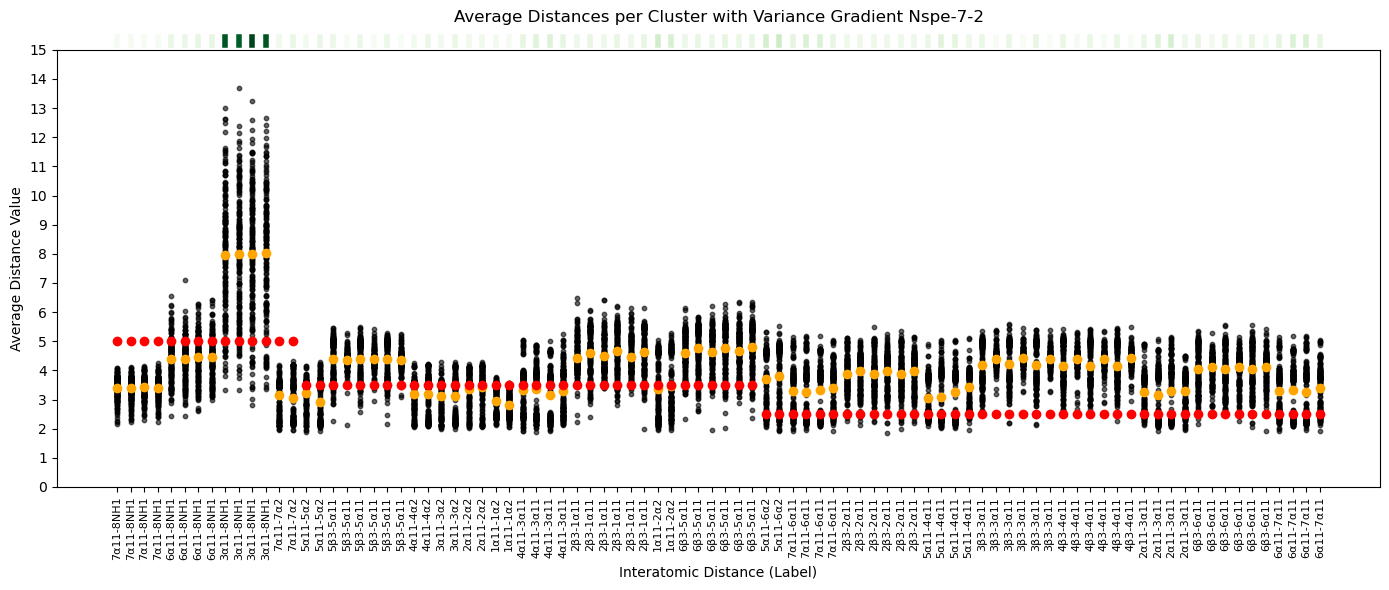

In [56]:
mean_across_clusters = average_distances_array.mean(axis=1)     # shape (76,)
var_across_clusters = average_distances_array.var(axis=1)       # shape (76,)
# Normalize the variance values to 0–1 for colormap
norm = mcolors.Normalize(vmin=var_across_clusters.min(), vmax=var_across_clusters.max())
cmap = cm.Greens  # or another colormap
colors = cmap(norm(var_across_clusters))  # shape: (76, 4) — RGBA colors


plt.figure(figsize=(14, 6))


# Scatter plot: one color per cluster
for j, label_id in enumerate(cluster_labels):
    plt.scatter(range(90), average_distances_array[:, j], color='black',
            s=10, alpha=0.6)
plt.scatter(range(90), mean_across_clusters, color='orange')
plt.scatter(range(90), targets, color='red')
for i in range(90):
    plt.axvline(x=i, ymin=1.01, ymax=1.03, color=colors[i], linewidth=4, clip_on=False)


# X-axis ticks as human-readable labels
plt.xticks(ticks=np.arange(90), labels=labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(0, plt.ylim()[1] + 1, 1))  # interval = 1
plt.xlabel("Interatomic Distance (Label)")
plt.ylabel("Average Distance Value")
plt.title("Average Distances per Cluster with Variance Gradient Nspe-7-2", pad=20)
plt.tight_layout()
plt.savefig("fig/Average_Distances_per_Cluster_with _Variance_Gradient_nspe72.png", dpi=300)
plt.show()


In [57]:
average_distances_array_T = average_distances_array.T 
print('average_distances_array_T.shape', average_distances_array_T.shape)

rmsd = np.sqrt(np.mean((average_distances_array_T - targets) ** 2, axis=1))
rmsd.shape



average_distances_array_T.shape (181, 90)


(181,)

In [58]:
# Get indices of clusters sorted by RMSD
sorted_indices = np.argsort(rmsd)

# Get the smallest five
top5_indices = sorted_indices[:5]
top5_indices = np.array([ 1, 49,  7,  0, 71])
top5_indices = np.array([ 1])
top5_rmsd = rmsd[top5_indices]

# Print them
for rank, (idx, val) in enumerate(zip(top5_indices, top5_rmsd), 1):
    print(f"{rank}. Cluster {idx} → RMSD = {val:.4f}")

top5_indices


1. Cluster 1 → RMSD = 1.1609


array([1])

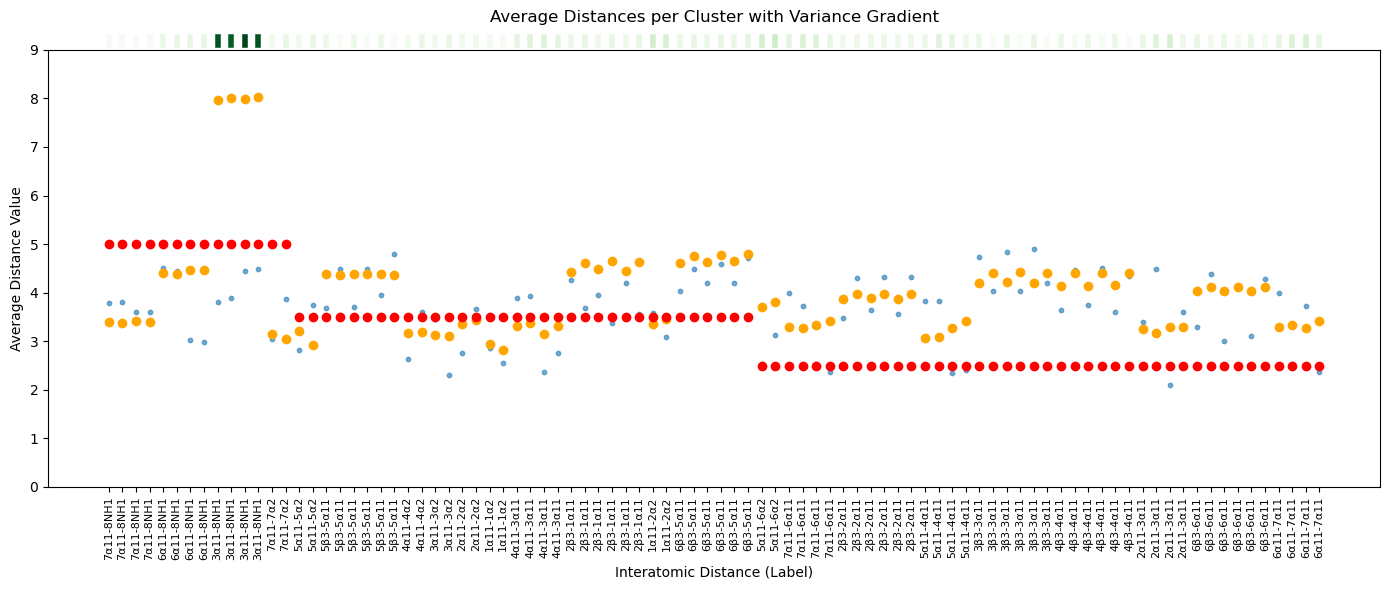

In [59]:
mean_across_clusters = average_distances_array.mean(axis=1)     # shape (76,)
var_across_clusters = average_distances_array.var(axis=1)       # shape (76,)
# Normalize the variance values to 0–1 for colormap
norm = mcolors.Normalize(vmin=var_across_clusters.min(), vmax=var_across_clusters.max())
cmap = cm.Greens  # or another colormap
colors = cmap(norm(var_across_clusters))  # shape: (76, 4) — RGBA colors


plt.figure(figsize=(14, 6))


# Only plot top 5 lowest-RMSD clusters
for cluster_idx in top5_indices:
    plt.scatter(range(90), average_distances_array_T[cluster_idx], 
                s=10, alpha=0.6, label=f'Cluster {cluster_idx}')
plt.scatter(range(90), mean_across_clusters, color='orange')
plt.scatter(range(90), targets, color='red')
for i in range(90):
    plt.axvline(x=i, ymin=1.01, ymax=1.03, color=colors[i], linewidth=4, clip_on=False)


# X-axis ticks as human-readable labels
plt.xticks(ticks=np.arange(90), labels=labels, rotation=90, fontsize=8)
plt.yticks(ticks=np.arange(0, plt.ylim()[1] + 1, 1))  # interval = 1
plt.xlabel("Interatomic Distance (Label)")
plt.ylabel("Average Distance Value")
plt.title("Average Distances per Cluster with Variance Gradient", pad=20)
plt.tight_layout()
plt.show()


## Analaysis Each Cluster Distance Distribution

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

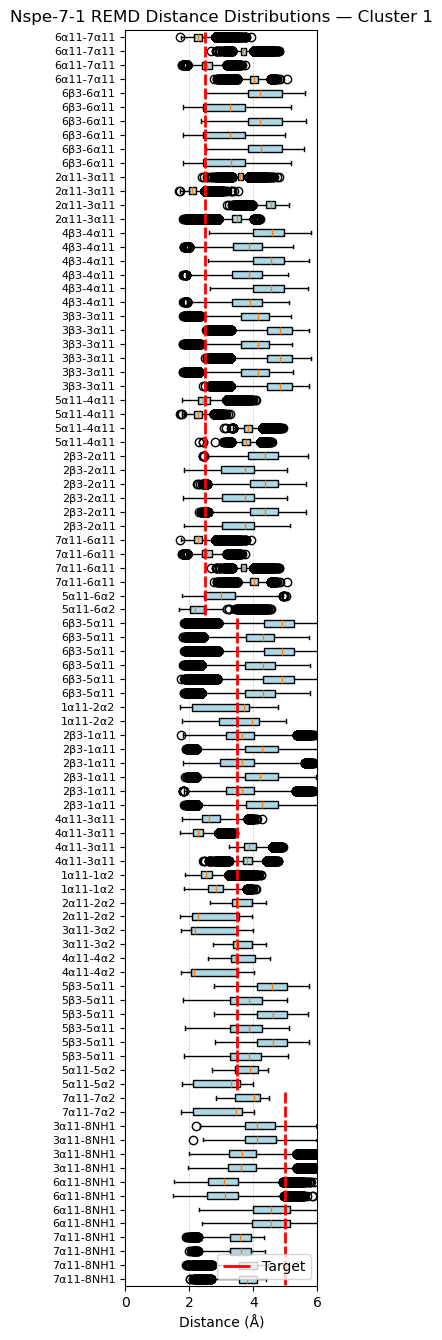

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

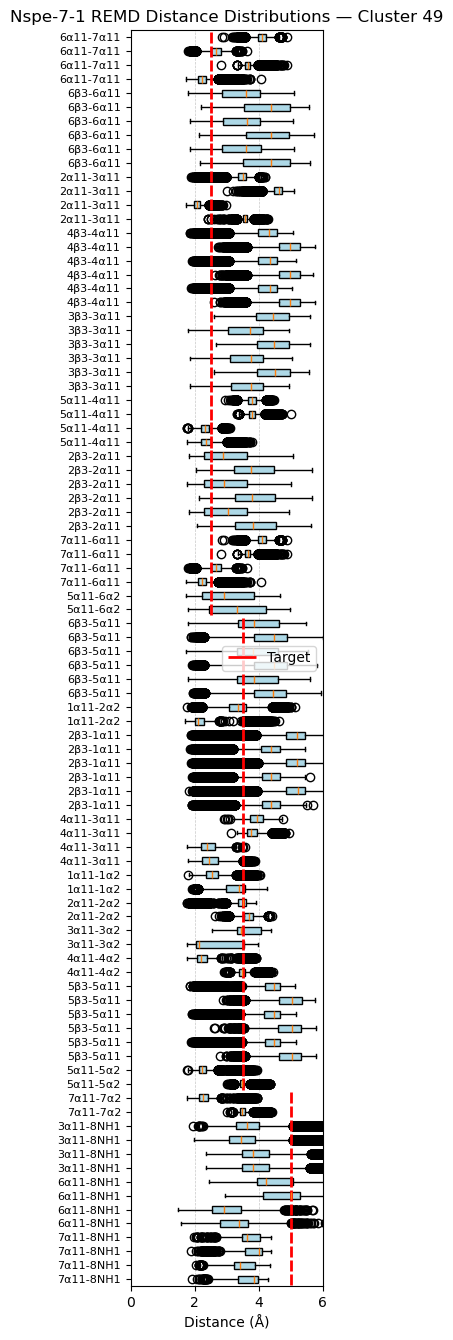

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

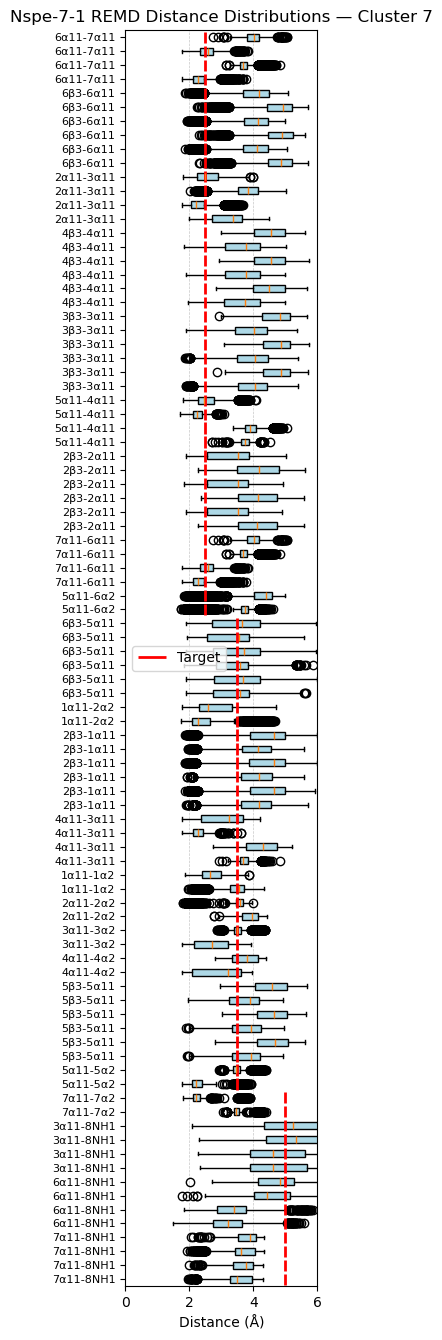

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

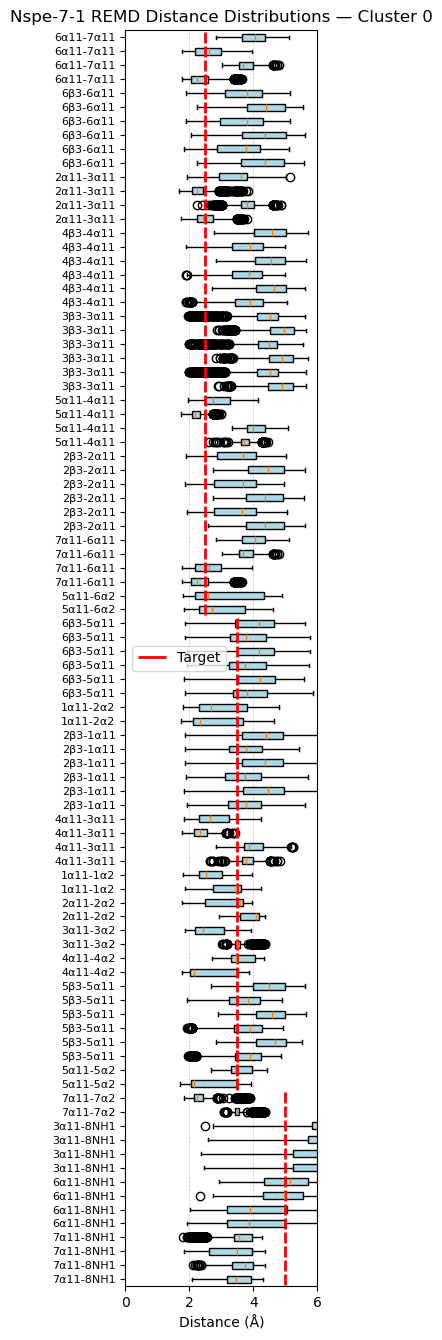

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

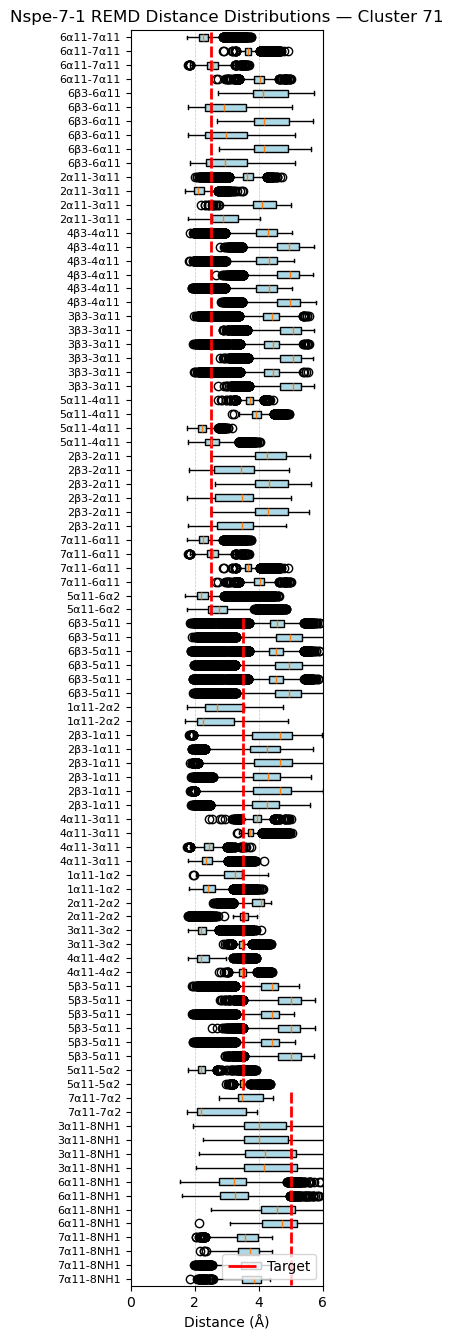

In [60]:
human_interpretable_label = True
grofile = "../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"

for cluster_label, frame_indices in top_cluster.items():
    targets = []
    labels = []
    all_dists = []

    cluster_feat = feat_all[frame_indices]
    dist_feat = cluster_feat[:, :90]

    for i, (atom1, atom2, target) in enumerate(dist_res):
        dist = dist_feat[:, i]
        all_dists.append(dist)
        targets.append(target)

        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label = feat.describe()[0]

        if human_interpretable_label:
            #labels.append(f"{i}: {translate_pyemma_label(label=label)}")
            labels.append(f"{translate_pyemma_label(label=label)}")
        else:
            labels.append(label)

    targets = np.array(targets)

    plt.figure(figsize=(3, max(6, len(labels) * 0.15)))

    # Boxplot: transpose the list of arrays into required format
    bp = plt.boxplot(all_dists, vert=False, patch_artist=True, labels=labels)

    # Custom styling for boxes
    for box in bp['boxes']:
        box.set(facecolor='lightblue')

    # Add red target lines
    for yi, ti in enumerate(targets, start=1):  # boxplot y starts at 1
        plt.vlines(ti, yi - 0.4, yi + 0.4, colors='red', linestyles='-', linewidth=2, label='Target' if yi == 1 else "")

    plt.yticks(fontsize=8)
    plt.xlabel("Distance (Å)")
    plt.title(f"Nspe-7-1 REMD Distance Distributions — Cluster {cluster_label}")
    plt.xlim(0, 6)
    plt.legend()
    plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.show()


## Analysis Dihedral

In [77]:
def plot_dihedral_quadruplets(
    omega_all,
    residues_to_plot,
    states=range(16),
    use_latex=True,
    angles_to_plot=None,
    save=False,
    cluster_label=cluster_label
):
    """
    Plot selected dihedral angle pairs for each residue in each state.

    Parameters:
    -----------
    omega_all : np.ndarray
        Shape (n_states, n_frames, n_dihedrals)
    residues_to_plot : list of int
        Starting indices of each residue block (omega, phi, psi, chi1)
    states : list
        Indices of states to plot
    use_latex : bool
        Use LaTeX formatting for labels
    angles_to_plot : list of str
        Angle pairs to plot. Options:
            'omega_phi', 'omega_psi', 'phi_psi',
            'omega_chi1', 'phi_chi1', 'psi_chi1'
    """
    if angles_to_plot is None:
        angles_to_plot = ["omega_phi", "omega_psi", "phi_psi", "omega_chi1", "phi_chi1", "psi_chi1"]

    scatter_kws = dict(s=2, color='black', alpha=0.3)

    # Axis labels
    if use_latex:
        labels = {
            'phi': r'$\phi$',
            'psi': r'$\psi$',
            'omega': r'$\omega$',
            'chi1': r'$\chi_1$'
        }
    else:
        labels = {
            'phi': 'Phi',
            'psi': 'Psi',
            'omega': 'Omega',
            'chi1': 'Chi1'
        }

    def format_ax(ax, xlabel, ylabel):
        """Set axis limits and ticks based on dihedral type."""
        if labels['phi'] in xlabel:
            ax.set_xlim(-180, 180)
            ax.set_xticks(np.arange(-180, 181, 180))
        else:
            ax.set_xlim(-90, 270)
            ax.set_xticks(np.arange(-90, 271, 180))

        if labels['phi'] in ylabel:
            ax.set_ylim(-180, 180)
            ax.set_yticks(np.arange(-180, 181, 180))
        else:
            ax.set_ylim(-90, 270)
            ax.set_yticks(np.arange(-90, 271, 180))

        ax.set_xlabel(xlabel, labelpad=4)
        ax.set_ylabel(ylabel, labelpad=4)

    # Mapping from angle pair name to (x, y) keys and title suffix
    angle_plot_map = {
        'omega_phi':   ('phi',   'omega'),
        'omega_psi':   ('psi',   'omega'),
        'phi_psi':     ('psi',   'phi'),
        'omega_chi1':  ('chi1',  'omega'),
        'phi_chi1':    ('chi1',  'phi'),
        'psi_chi1':    ('chi1',  'psi'),
    }

    for state_idx in states:
        num_residues = len(residues_to_plot)
        num_pairs = len(angles_to_plot)
        nrows = num_residues
        ncols = num_pairs

        fig, axes = plt.subplots(nrows, ncols, figsize=(1.8 * ncols, 1.2 * nrows), sharex='col')
        axes = np.atleast_2d(axes)

        fig.suptitle(f'Nspe_7_2 — Cluster {cluster_label} REMD Dihedral Scatter Plot', fontsize=10)

        for row_idx, residue in enumerate(residues_to_plot):
            omega = omega_all[state_idx, :, residue]
            phi   = omega_all[state_idx, :, residue + 1]
            psi   = omega_all[state_idx, :, residue + 2]
            chi1  = omega_all[state_idx, :, residue + 3]

            angle_data = {
                'omega': omega,
                'phi':   phi,
                'psi':   psi,
                'chi1':  chi1,
            }

            for col_idx, angle_pair in enumerate(angles_to_plot):
                x_key, y_key = angle_plot_map[angle_pair]
                x = angle_data[x_key]
                y = angle_data[y_key]
                ax = axes[row_idx, col_idx]
                ax.scatter(x, y, **scatter_kws)
                format_ax(ax, labels[x_key], labels[y_key])

                if row_idx == 0:
                    ax.set_title(f'{labels[y_key]} vs {labels[x_key]}')
                if col_idx == 0:
                    ax.set_ylabel(f'Res {residue//4}\n{labels[y_key]}')

        fig.tight_layout()
        #fig.subplots_adjust(wspace=0)  # adds horizontal space between columns
        plt.show()
        if save:
            fig.savefig(f"fig/Nspe-7-2_state{cluster_label}_dihedral_scatter_plot.pdf")



Plotting Cluster 1 with 54876 frames


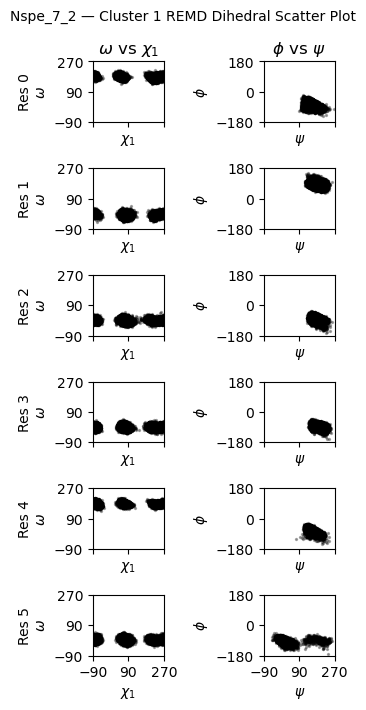

Plotting Cluster 49 with 14993 frames


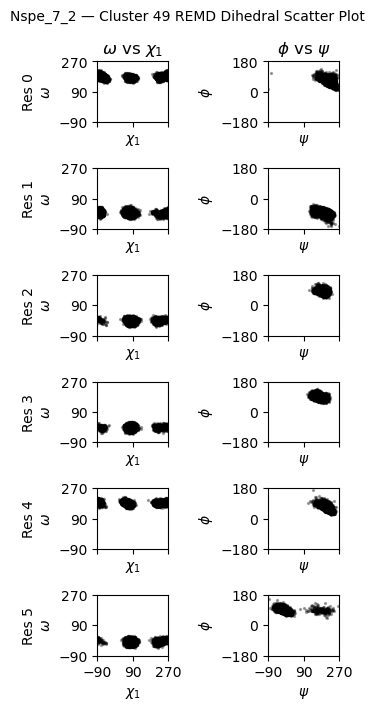

Plotting Cluster 7 with 2655 frames


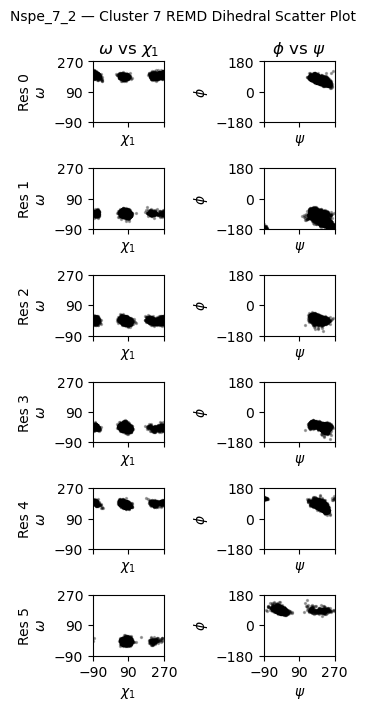

Plotting Cluster 0 with 2115 frames


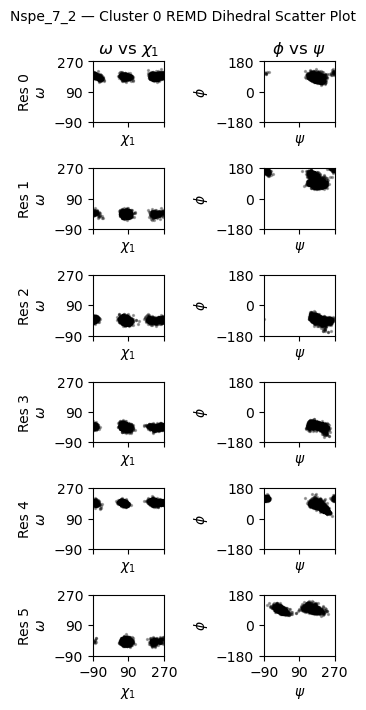

Plotting Cluster 71 with 8543 frames


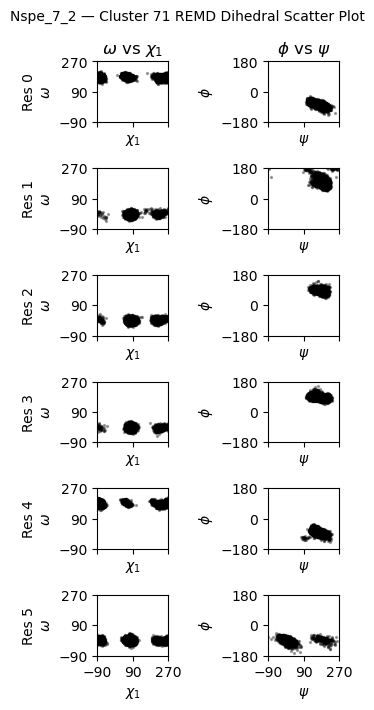

In [71]:
# Available options for angles_to_plot:

# "phi_psi"      # Plot ψ vs φ
# "omega_phi"    # Plot φ vs ω
# "omega_psi"    # Plot ψ vs ω
# "omega_chi1"   # Plot χ₁ vs ω
# "phi_chi1"     # Plot χ₁ vs φ
# "psi_chi1"     # Plot χ₁ vs ψ

residues_to_plot = np.arange(0, 24, 4).tolist()  # Modify if needed



angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for label, indices in top_cluster.items():
    omega_input = omegas[indices, :][np.newaxis, ...]  # shape becomes (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {indices.shape[0]} frames")

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot,
        cluster_label=label
    )

## Filter The Cluster Based On RMSD

In [72]:
## Create the equivalent proton set
restraint_index = pd.factorize(labels)[0] + 1
print(restraint_index)

## Creat their weight
counts = pd.Series(restraint_index).value_counts()
weights = pd.Series(restraint_index).map(lambda x: 1 / counts[x])
weights = weights.to_list()
print("Weights:", weights)

## Prepare Target/ Experimental NMR Distance 
print('NMR Distance', targets)

[ 1  1  1  1  2  2  2  2  3  3  3  3  4  4  5  5  6  6  6  6  6  6  7  7
  8  8  9  9 10 10 11 11 11 11 12 12 12 12 12 12 13 13 14 14 14 14 14 14
 15 15 16 16 16 16 17 17 17 17 17 17 18 18 18 18 19 19 19 19 19 19 20 20
 20 20 20 20 21 21 21 21 22 22 22 22 22 22 23 23 23 23]
Weights: [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.5, 0.5, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.16666666666666666, 0.25, 0.25,

In [73]:
filtered_cluster = {label: [] for label in top_cluster}

for cluster_label, frame_indices in top_cluster.items():
    rmsd_list = []

    for idx in frame_indices:
        dist = feat_all[idx, :90]  # predicted distances
        diff = dist - targets      # element-wise difference
        weighted_sq_diff = weights * (diff ** 2)
        rmsd_value = np.sqrt(np.sum(weighted_sq_diff) / np.sum(weights))

        # Save both index and RMSD
        rmsd_list.append((idx, rmsd_value))

    # Sort by RMSD value and take the lowest 20
    sorted_rmsd = sorted(rmsd_list, key=lambda x: x[1])[:10]
    print(f"{cluster_label} cluster rmsd {sorted_rmsd}")
    # Append only the indices of the lowest 20 RMSDs
    filtered_cluster[cluster_label] = [idx for idx, _ in sorted_rmsd]

1 cluster rmsd [(7013, 1.0010692453703178), (45306, 1.0058391915568923), (65460, 1.010841365340082), (144867, 1.0114904799135787), (65443, 1.0147531323366976), (65423, 1.015145272671793), (130832, 1.016514168720316), (163930, 1.0191224260177547), (142438, 1.0224395465805087), (153850, 1.027315818576228)]
49 cluster rmsd [(125953, 1.0631638995852928), (194562, 1.0635515428751072), (122859, 1.0830278484868572), (194424, 1.0927304808657665), (167026, 1.0952796841705001), (126636, 1.0962296664091007), (125894, 1.0965883130724188), (33394, 1.0974038875970362), (169174, 1.0990748516878568), (34567, 1.0998436700032634)]
7 cluster rmsd [(3982, 1.0691594242769775), (5545, 1.0879901400369159), (5054, 1.0895058757098728), (5111, 1.09214231602947), (5498, 1.0924385399197287), (5496, 1.0931279143106796), (4214, 1.1000185997084182), (2923, 1.1045144157837523), (2387, 1.1063890431958106), (14912, 1.111300744883546)]
0 cluster rmsd [(58, 1.0575107676558502), (170, 1.0663293994444498), (500, 1.07239552

### Plot

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

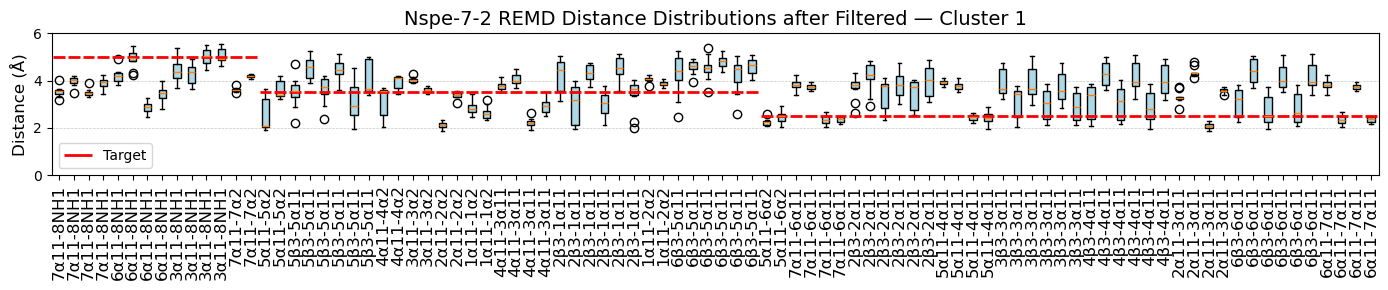

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

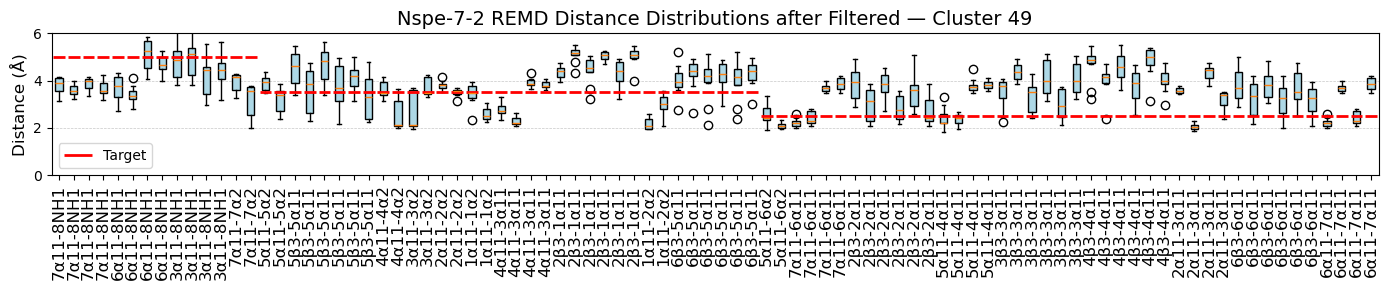

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

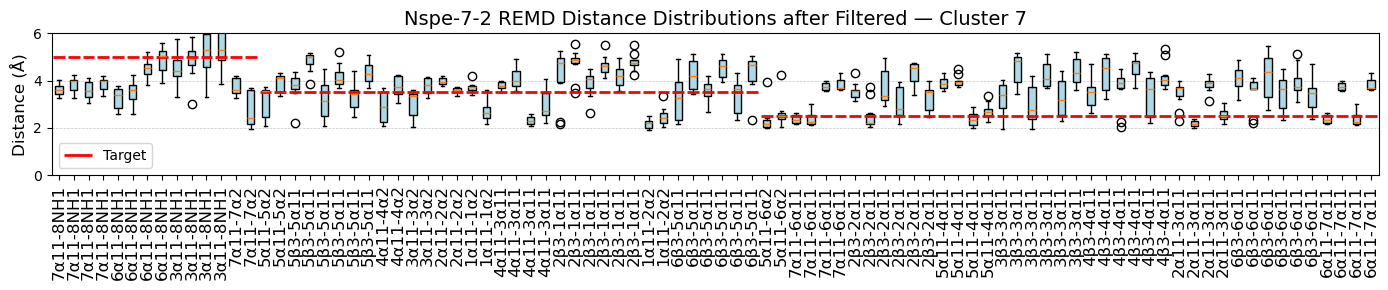

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

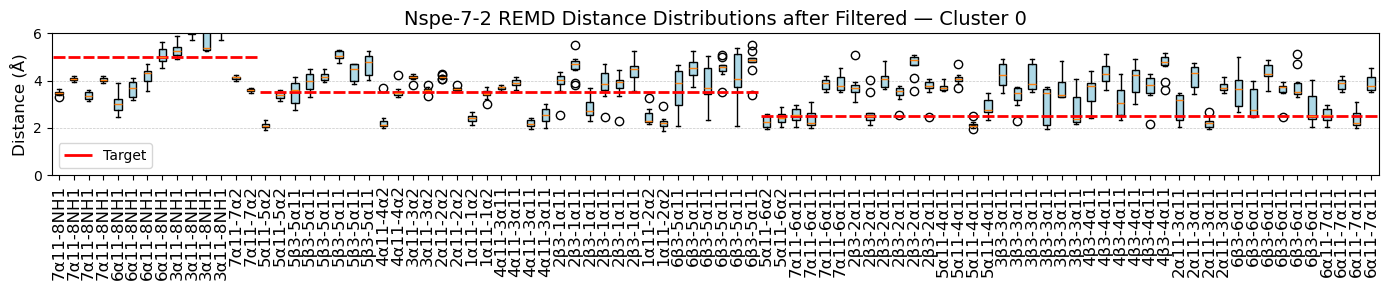

Label: R02 7 H10 159 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H10 159 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H10 (159), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN1 164
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 7 H11 160 - NH2 8 HN2 165
Residue 1: R02 7, Atom: H11 (160), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H10 136 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H10 (136), Group: α11
Residue 2: NH2 8, Atom: HN2 (165), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN1 164
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2 8, Atom: HN1 (164), Group: NH1
Label: R02 6 H11 137 - NH2 8 HN2 165
Residue 1: R02 6, Atom: H11 (137), Group: α11
Residue 2: NH2

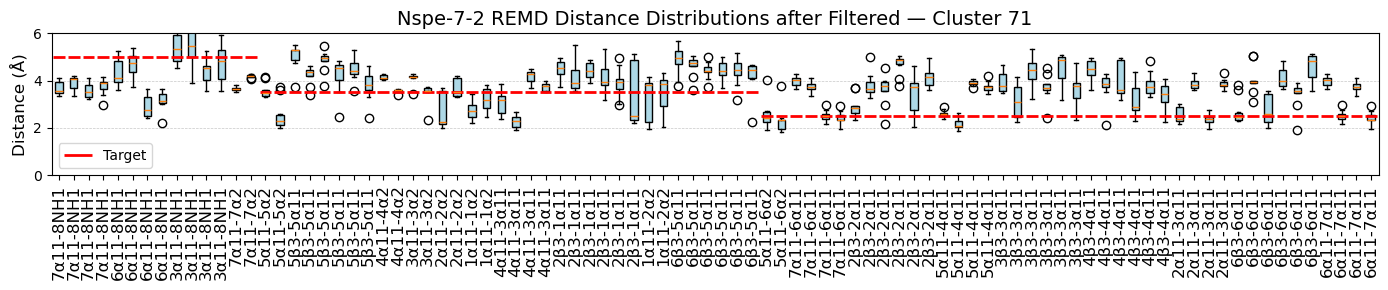

In [74]:
human_interpretable_label = True
grofile = "../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"

for cluster_label, frame_indices in filtered_cluster.items():
    targets = []
    labels = []
    all_dists = []

    cluster_feat = feat_all[frame_indices]
    dist_feat = cluster_feat[:, :90]

    for i, (atom1, atom2, target) in enumerate(dist_res):
        dist = dist_feat[:, i]
        all_dists.append(dist)
        targets.append(target)

        atom1_pyemma = atom1 - 1
        atom2_pyemma = atom2 - 1
        feat = pyemma.coordinates.featurizer(grofile)
        feat.add_distances([[atom1_pyemma, atom2_pyemma]])
        label = feat.describe()[0]

        if human_interpretable_label:
            #labels.append(f"{i}: {translate_pyemma_label(label=label)}")
            labels.append(f"{translate_pyemma_label(label=label)}")
        else:
            labels.append(label)

    targets = np.array(targets)

    ### SAVE DATA to .npz for this cluster
    np.savez(
        f"fig/cluster_{cluster_label}_distance_data.npz",
        all_dists=np.array(all_dists, dtype=object),  # store ragged arrays safely
        targets=targets,
    )


    plt.figure(figsize=(14, 3))  # wider horizontally

    # Vertical boxplot
    bp = plt.boxplot(all_dists, vert=True, patch_artist=True, labels=labels)

    # Custom styling for boxes
    for box in bp['boxes']:
        box.set(facecolor='lightblue')

    # Add red target lines (horizontal now)
    for xi, ti in enumerate(targets, start=1):  # x starts at 1 in vertical
        plt.hlines(ti, xi - 0.4, xi + 0.4, colors='red', linestyles='-', linewidth=2, label='Target' if xi == 1 else "")

    plt.xticks(fontsize=12, rotation=90)
    plt.ylabel("Distance (Å)", fontsize=12)
    plt.title(f"Nspe-7-2 REMD Distance Distributions after Filtered — Cluster {cluster_label}", fontsize=14)
    plt.ylim(0, 6)
    plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.legend()
    plt.savefig(f"fig/Nspe-7-2_REMD_Distance_Distributions_after_Filtered_Cluster_{cluster_label}.pdf", dpi=300)
    plt.show()


Plotting Cluster 1 with 10 frames


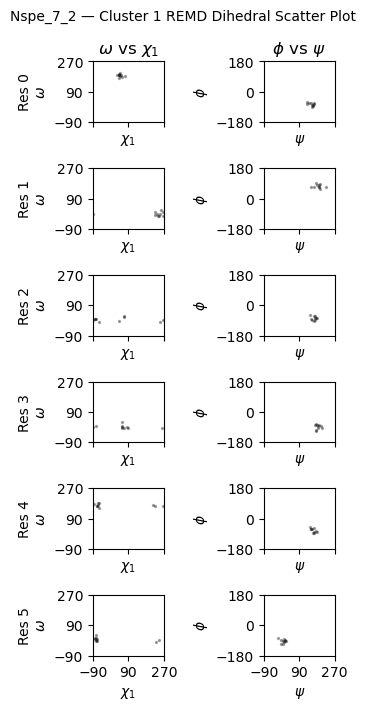

Plotting Cluster 49 with 10 frames


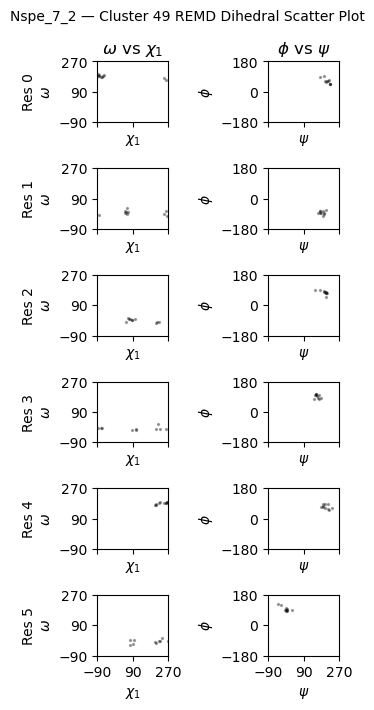

Plotting Cluster 7 with 10 frames


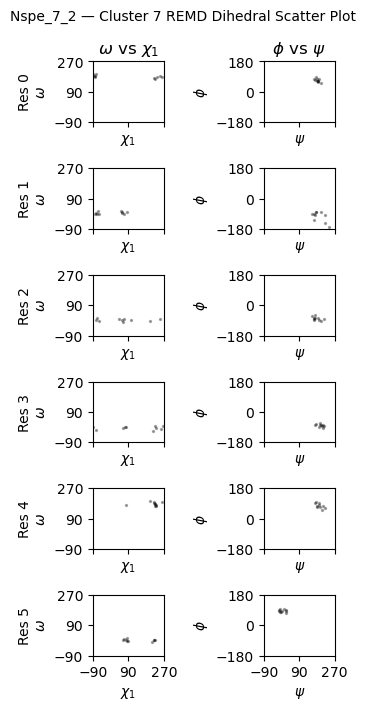

Plotting Cluster 0 with 10 frames


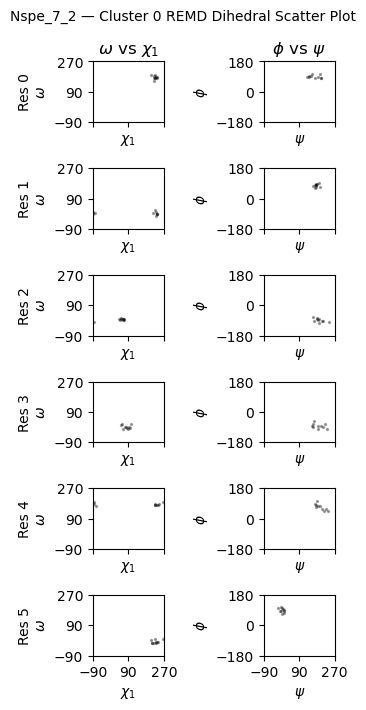

Plotting Cluster 71 with 10 frames


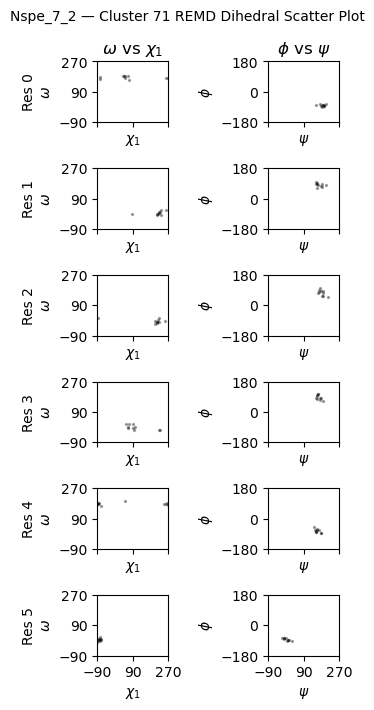

In [78]:
angles_to_plot = ["omega_chi1", "phi_psi"]  # customize as needed

for label, indices in filtered_cluster.items():
    omega_input = omegas[indices, :][np.newaxis, ...]  # shape becomes (1, n_frames, 24)

    print(f"Plotting Cluster {label} with {omega_input.shape[1]} frames")

    # ---- SAVE DATA ----
    np.savez(
        f"fig/cluster_{label}_angles_data.npz",
        omega_input=omega_input,
        residues_to_plot=np.array(residues_to_plot),
        angles_to_plot=np.array(angles_to_plot),
    )

    plot_dihedral_quadruplets(
        omega_all=omega_input,
        residues_to_plot=residues_to_plot,
        states=[0],  # Only 1 cluster at a time
        use_latex=True,
        angles_to_plot=angles_to_plot,
        cluster_label=label,
        save=1
    )


## Sampling

In [67]:
# Define the directory path
directory = "sampling/"

# Check if the directory exists
if os.path.exists(directory):
    # Remove all contents of the directory
    shutil.rmtree(directory)
    # Recreate the empty directory
    os.makedirs(directory)
    print(f"All contents in '{directory}' have been cleared.")
else:
    # Create the directory if it does not exist
    os.makedirs(directory)
    print(f"Directory '{directory}' did not exist, so it has been created.")

All contents in 'sampling/' have been cleared.


In [68]:
# Load all trajectories and join
HREX_dir = '../traj_remd'
run_num = 10
trajs = []
HREX_list = [f"REMD_200ns_{i}" for i in range(1, run_num + 1)]

for HREX in HREX_list:
    HREX_path = f"{HREX_dir}/{HREX}"  
    xtcfile = f"{HREX_path}/state_0/HREMD.part0001_intact.xtc"
    grofile = f"../nspe_7_2.amb2gmx/nspe_7_2_GMX.gro"
    traj = md.load(xtcfile, top=grofile)
    trajs.append(traj)

# Concatenate all trajectories
concatenated_trajs = md.join(trajs)

# Save sampled frames for each selected cluster using filtered_cluster
for label, frame_indices in filtered_cluster.items():
    print('label', label, "frame_indices", frame_indices)
    sampling = concatenated_trajs[frame_indices]  # extract frames
    sampling.save_xtc(f"sampling/nspe_7_2_sample_state_0_cluster{label}.xtc")
    sampling.save_pdb(f"sampling/nspe_7_2_sample_state_0_cluster{label}.pdb")



label 1 frame_indices [7013, 45306, 65460, 144867, 65443, 65423, 130832, 163930, 142438, 153850]
label 49 frame_indices [125953, 194562, 122859, 194424, 167026, 126636, 125894, 33394, 169174, 34567]
label 7 frame_indices [3982, 5545, 5054, 5111, 5498, 5496, 4214, 2923, 2387, 14912]
label 0 frame_indices [58, 170, 500, 603, 172, 230, 499, 503, 171, 125]
label 71 frame_indices [142341, 94290, 142409, 142288, 142343, 169384, 142340, 120972, 142336, 142334]
